# Sequence Modeling

## Start with the prediction question, not the architecture

Suppose you have a machine's measurements in time order. You might want to classify the whole run as normal or faulty, identify the instant a fault began, or predict the next temperature. These questions use the same observations but require different targets, readouts, and evaluation rules.

A **sequence** is an ordered collection of observations. Order can represent time, word position, or event position. A **sequence modeling task** specifies how those observations relate to the outputs we want. An RNN, LSTM, GRU, convolution, or Transformer is a possible implementation, not a complete definition of the task.

This lesson works through input/target alignment, chronological splits, train-only scaling, baseline predictions, padded batches, and generation. We will use small numbers you can inspect by hand before connecting them to the [code companion](25_Sequence_Modeling.ipynb).

The companion deliberately uses a fixed-window feed-forward network. A sequence task does not require a recurrent architecture: a fixed window can be a useful baseline when it contains the history needed for prediction. [LSTM Networks](23_LSTM_Networks_Notes.ipynb) and [GRU Networks](24_GRU_Networks_Notes.ipynb) provide alternatives for representing histories.


## See the four common task shapes

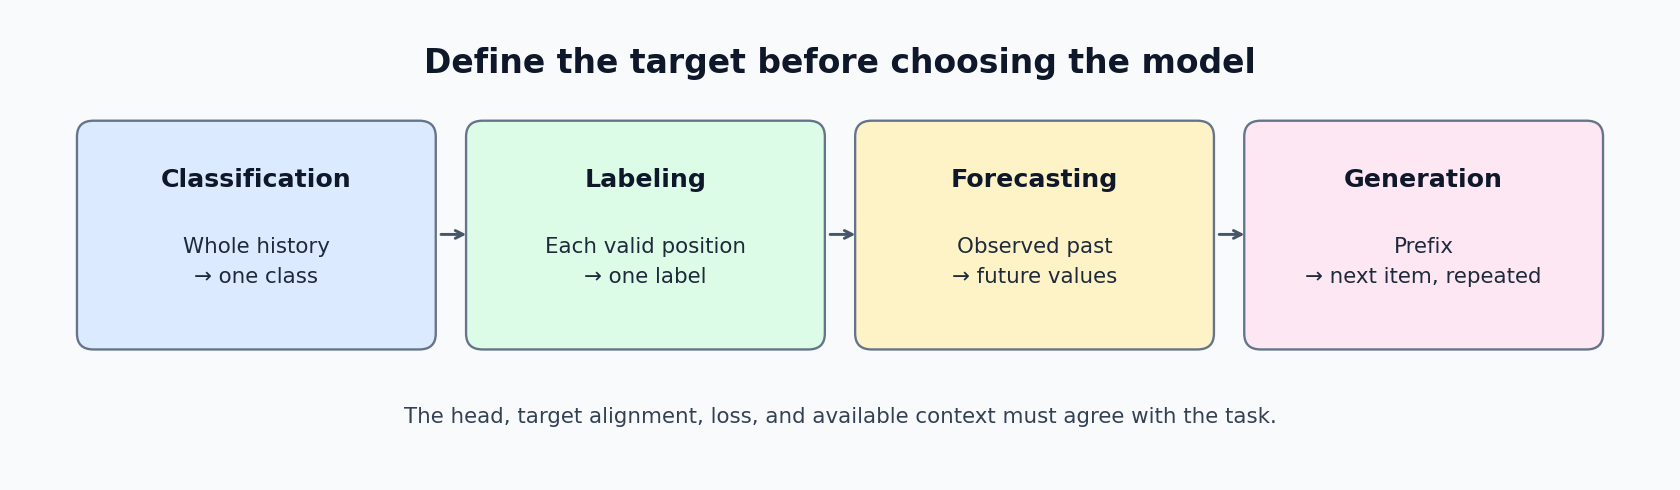

| Task | What is available? | What is predicted? | Example |
| --- | --- | --- | --- |
| Sequence classification | A complete history or observed prefix | One label | Is this run faulty? |
| Sequence labeling | Observations at positions | One label per valid position | Tag each event type |
| Forecasting | Observations available before a target time | Future numerical values | Predict next-hour demand |
| Generation | A prefix of symbols or observations | A next item, repeatedly | Continue a text sequence |

“Many-to-one” describes several inputs feeding one output. “Many-to-many” describes outputs across positions or a multi-position output sequence. These labels are useful sketches, but they do not tell us whether future context is permitted or how far ahead the prediction goes.

For every task, write one sentence specifying the prediction time and information available at that time. This becomes the contract that the dataset, model, and evaluation must obey.


## State the information contract explicitly

Imagine predicting tomorrow's demand at tonight's closing time. Past demand is available. Tomorrow's realized demand is not. Calendar information for tomorrow may already be known, but tomorrow's realized weather may not be; a weather forecast available tonight is a different feature.

| Feature | Available at forecast time? | Decision |
| --- | --- | --- |
| Demand through tonight | Yes | Can be history |
| Tomorrow's weekday | Yes | Can be a future-known covariate |
| Tomorrow's actual demand | No | Must be a target, not an input |
| Tomorrow's measured weather | No | Exclude unless the evaluation permits it |
| Weather forecast issued tonight | Yes | Can be used with its issue time recorded |

For offline sequence labeling, the complete sentence may be available. For online event detection, future events are unavailable. A bidirectional recurrent model can be appropriate for the first task and violate the information contract of the second.

Leakage means allowing the training or evaluation pipeline to use information that the stated prediction setting would not provide. It can arise through feature construction, splitting, normalization, or model selection, not just through an obvious target column.


## Build one-step examples without an off-by-one error

Let observations be $[2,3,5,4,6]$, indexed from zero, and let the context window length be three. The training pairs are:

| Target index | Input indices | Input values | Target value |
| --- | --- | --- | --- |
| 3 | 0, 1, 2 | $[2,3,5]$ | 4 |
| 4 | 1, 2, 3 | $[3,5,4]$ | 6 |

In general, if $j$ is the target index and $k$ is the window length:

$$X_j=[x_{j-k},\ldots,x_{j-1}],\qquad y_j=x_j.$$

The input ends just before the target. A common mistake is to include $x_j$ in its own input window; another is to shift the target by the wrong number of positions.

For a series of length $N$, one-step windows without padding produce $N-k$ examples. With $N=5$ and $k=3$, there are two. Adjacent windows share observations, so they are related views of one history rather than independent series.

Before training, print the first and last input/target pair in every split. Small alignment mistakes can produce plausible-looking losses while solving the wrong problem.


## Distinguish horizon length from context length

The context length describes how much past information is supplied. The forecast horizon describes how far into the future the output reaches. They need not be equal.

For the sequence $[2,3,5,4,6,7]$, context length three and horizon two produce:

| Input | Two-step target |
| --- | --- |
| $[2,3,5]$ | $[4,6]$ |
| $[3,5,4]$ | $[6,7]$ |

A direct multi-output model maps one input window to both future values. A recursive model predicts the first value, adds that prediction to its context, and predicts again. The recursive approach may accumulate errors because later steps consume earlier predictions.

If all horizon targets must fit inside a series of length $N$, the number of windows is $N-k-H+1$, where $H$ is the horizon length. Here it is $6-3-2+1=2$.

For split design, decide where the entire target interval belongs. A window whose first target is in training and second target in validation should not quietly cross the target boundary. Either exclude it or define a protocol that keeps the target block within its assigned split.


## Split by target time for a future-prediction task

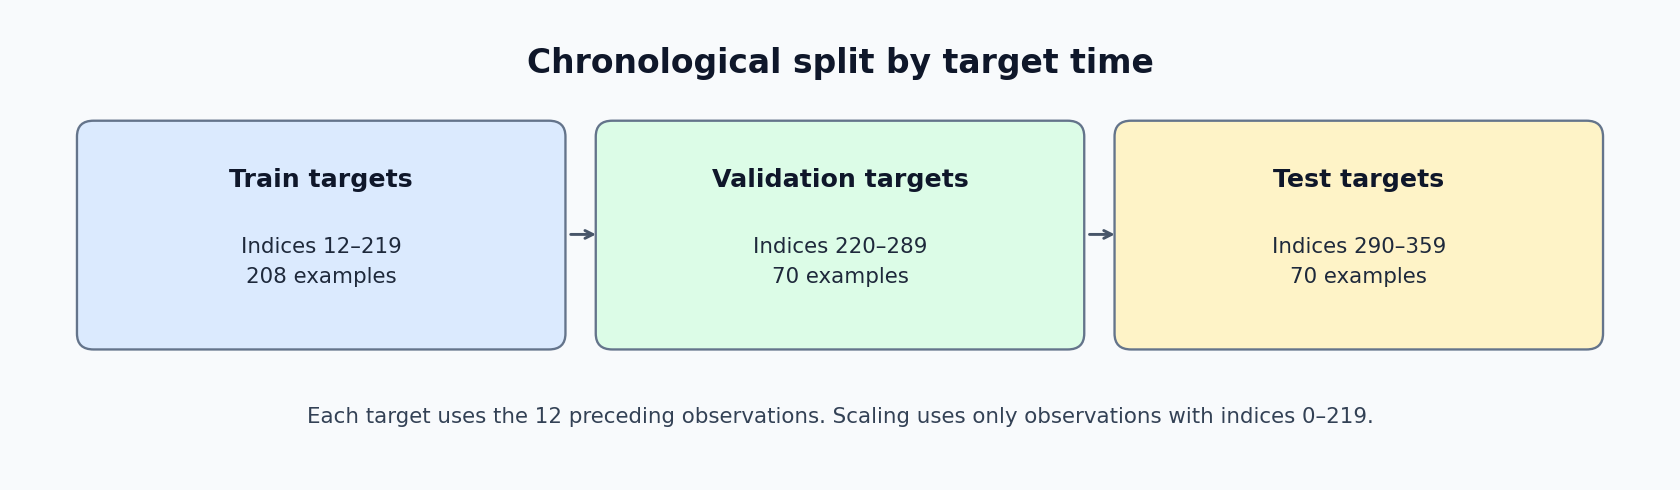

The companion has 360 observations, a 12-step context, training boundary 220, and validation boundary 290. All boundaries are zero-based, and interval endpoints are excluded in the Python slicing convention.

| Split | Target indices | Number of examples | First context indices |
| --- | --- | --- | --- |
| Training | 12 through 219 | 208 | 0 through 11 |
| Validation | 220 through 289 | 70 | 208 through 219 |
| Test | 290 through 359 | 70 | 278 through 289 |

Validation begins with a context drawn from the end of training observations. This is legitimate for the companion's rolling one-step setting: those observations happened before the validation target. Later test windows also use earlier test observations because those values are assumed to have become available before the next forecast.

That protocol is different from predicting the whole test region once at index 290 without seeing subsequent observations. For that fixed-origin, multi-step setting, later actual test values cannot be fed back as context. State the protocol before interpreting a forecast score.


## Choose splits that match the source of dependence

Randomly distributing neighboring windows across training and test is usually a poor match for future forecasting. It mixes nearby regimes and can place later history into the training data while evaluating earlier history.

| Intended deployment | Useful split unit | Why |
| --- | --- | --- |
| Future of one ongoing series | Chronological target time | Measures forward prediction |
| New machine or patient | Machine or patient identifier | Prevents source overlap |
| New document | Document identifier | Keeps related positions together |
| New event pattern | Pattern/template family | Tests more than memorized templates |

The correct split is task-dependent. Overlap in earlier context is not automatically leakage when that history is available at the forecast time. But target overlap, future information in preprocessing, or repeated independent-source identifiers can invalidate a claimed evaluation.

For evolving series, rolling-origin evaluation repeats the train/validation/test exercise at several cutoffs. This reveals whether performance depends strongly on one convenient period. Choose any gap or embargo based on overlapping target intervals and how the information actually becomes available.


## Fit preprocessing using training observations only

A standardized value is:

$$x'=\frac{x-\mu_{train}}{s_{train}}.$$

Both the mean and scale must be fitted from permitted training observations, then reused without refitting for validation and test. Choosing a constant transformation in advance is different from estimating it from the full dataset.

For a small illustration, training observations $[2,3,5]$ have mean $10/3\approx3.3333$. Using the sample standard deviation, their squared deviations sum to $14/3$, giving variance $7/3$ and scale $\sqrt{7/3}\approx1.527525$.

| Original value | Standardized value using training statistics |
| --- | --- |
| 2 | -0.872872 |
| 3 | -0.218218 |
| 5 | 1.091089 |
| 4, a later target | 0.436436 |
| 6, a later target | 1.745743 |

The companion computes its statistics from raw observations at indices 0 through 219. It scales both contexts and targets with those fixed values. It does not recompute statistics for each validation or test window. Fit statistics on the chosen raw training observations rather than accidentally weighting some observations several times through overlapping windows.


## Make a baseline prediction before training a network

A **persistence baseline** predicts that the next observation equals the last observed value. For the two original windows, it predicts 5 for target 4 and 4 for target 6.

| Window | Target | Persistence prediction | Error: prediction minus target | Squared error |
| --- | --- | --- | --- | --- |
| $[2,3,5]$ | 4 | 5 | 1 | 1 |
| $[3,5,4]$ | 6 | 4 | -2 | 4 |

Mean squared error is $(1+4)/2=2.5$. Mean absolute error is $(1+2)/2=1.5$. Root mean squared error is $\sqrt{2.5}\approx1.581139$.

Suppose a proposed model instead predicts 4.5 and 5.5. Its MSE is $(0.25+0.25)/2=0.25$ and MAE is 0.5. It improves this tiny example, but two points are not sufficient evidence of reliable forecasting.

Other useful baselines include a training-set mean, a seasonal last-value forecast, or a simple linear predictor. A model should earn its complexity by improving a baseline under the same input availability and split protocol.


## Follow a small learning update from window to loss

To expose one training step, use a simple head that reads only the last context value: $\hat y=w x_{last}+b$. For window $[2,3,5]$, target 4, $w=1$, and $b=0$, the prediction is 5.

Use squared error $L=(\hat y-y)^2$ for this single example. Then:

$$\frac{\partial L}{\partial\hat y}=2(5-4)=2,$$
$$\frac{\partial L}{\partial w}=2\times5=10,\qquad\frac{\partial L}{\partial b}=2.$$

With learning rate 0.01, SGD gives $w_{new}=0.9$ and $b_{new}=-0.02$. Repeating the forward calculation yields $\hat y_{new}=0.9(5)-0.02=4.48$, so the new loss is $0.48^2=0.2304$.

This improves the first example, but the second example needs an upward correction from 4 toward 6. Training must balance examples rather than assume one local improvement helps every window. Batch-mean MSE averages the per-example derivatives; a factor of one half in a differently defined squared loss would also change the gradient scale.


## Read tensor shapes and losses as a contract

| Task | Typical input shape | Head output shape | Target shape |
| --- | --- | --- | --- |
| Fixed-window regression MLP | $(B,KD)$ | $(B,1)$ | $(B,)$ after squeezing output |
| Recurrent sequence classification | $(B,T,D)$ | $(B,C)$ | $(B,)$ integer classes |
| Sequence labeling | $(B,T,D)$ | $(B,T,C)$ | $(B,T)$ integer labels |
| Direct $H$-step scalar forecast | $(B,T,1)$ | $(B,H)$ | $(B,H)$ |

$B$ is batch size, $T$ is stored sequence length, $D$ is feature count, $C$ is class count, and $H$ is horizon length. The companion's scalar windows have shape $(B,12)$ because its MLP consumes twelve features directly. A recurrent layer would ordinarily receive $(B,12,1)$.

A regression output shaped $(B,1)$ and target shaped $(B,)$ can accidentally broadcast into a pairwise error matrix. Explicitly squeeze the final singleton dimension or reshape the target so the tensors match. A numerically finite loss does not prove the intended comparisons were made.

For cross-entropy, keep class logits and integer class indices aligned. For sequence labeling, arrange the class dimension or flatten valid positions as the chosen loss expects.


## Pad batches while preserving which positions are real

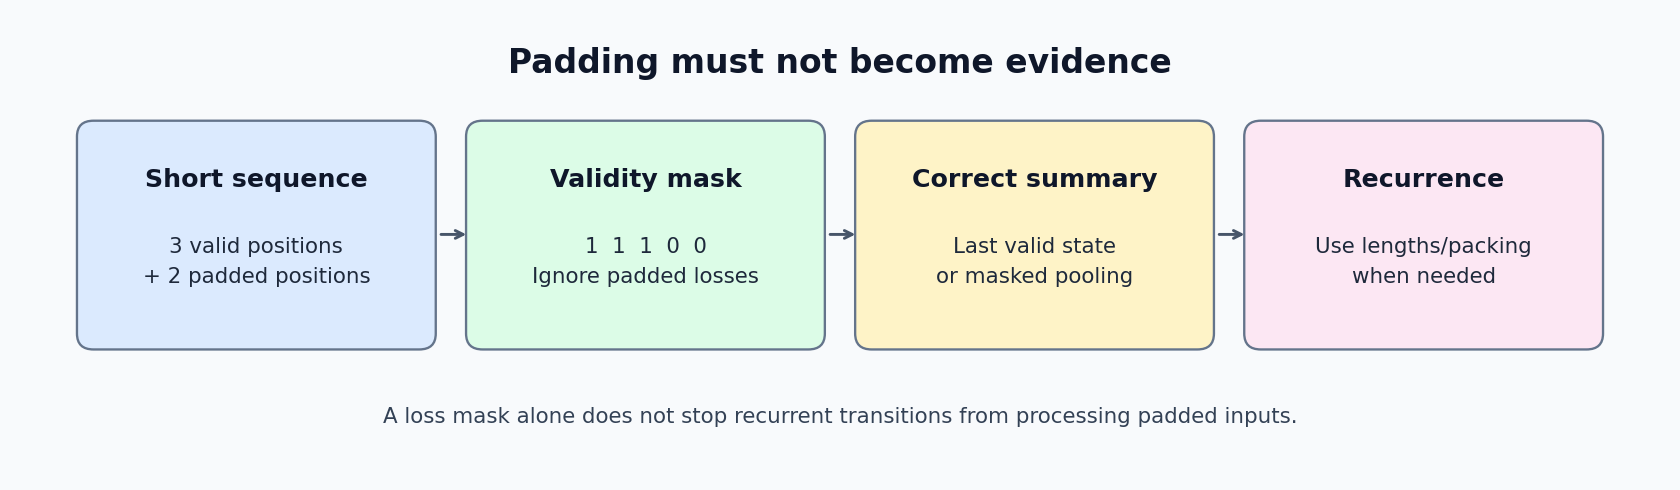

Suppose two scalar sequences are $[2,3,5]$ and $[1,4,2,6,3]$. After padding the first to length five:

| Example | Stored input | Validity mask | Valid length |
| --- | --- | --- | --- |
| A | $[2,3,5,0,0]$ | $[1,1,1,0,0]$ | 3 |
| B | $[1,4,2,6,3]$ | $[1,1,1,1,1]$ | 5 |

The value zero may also be a legitimate observation. The mask or lengths tell us which zeros are padding; the value alone cannot do that.

For a forward-only recurrent classifier, read the last valid state at index `length - 1`, or use a valid-position summary. For labeling, ignore padded targets in the loss. Packed recurrence can avoid processing padding. A loss mask alone does not prevent padded steps from altering hidden states.

For a pooled representation, divide the sum by the count of valid positions. Dividing by five for both examples would artificially shrink A's mean merely because it was stored next to a longer sequence.


## Choose the denominator of a masked loss deliberately

Let $m_{b,t}$ be one for valid targets and zero otherwise, and let $\ell_{b,t}$ be a position's loss. A mean over valid positions is:

$$L_{token}=\frac{\sum_{b,t}m_{b,t}\ell_{b,t}}{\sum_{b,t}m_{b,t}}.$$

Suppose A has valid losses $[1,3]$ and B has $[2,2,2,2]$. The valid-position mean is $(1+3+2+2+2+2)/6=2$. Dividing by all eight stored positions after padding A to length four would give 1.5, changing the objective just because padding was added.

A sequence-balanced mean first averages inside each sequence, then averages those means. Here both happen to equal 2. If A's losses were $[4,4]$ and B's losses remained four twos, the token mean would be $16/6\approx2.6667$, while the sequence-balanced mean would be $(4+2)/2=3$.

Neither weighting is universally correct. Position weighting gives longer sequences more contribution; sequence weighting gives each example equal contribution. Choose what reflects the task, and use a meaningful denominator with at least one valid target.


## Distinguish teacher forcing from free-running generation

An autoregressive model predicts the next item from earlier items:

$$p(x_1,\ldots,x_T)=\prod_{t=1}^{T}p(x_t\mid x_{<t}),$$

with an initial condition or start symbol supplying the beginning. During teacher-forced training, the context contains true previous items. During generation, the context includes items the model itself produced.

For a toy token sequence, training might use input `[START, cat, sat]` and target `[cat, sat, END]`. Every input position predicts the following token. If future tokens are visible through the architecture, the intended next-token task is violated even though the input and target arrays appear shifted correctly.

| Setting | Previous context | What the score measures |
| --- | --- | --- |
| Teacher-forced next-step evaluation | True earlier items | Conditional prediction with true history |
| Free-running generation | Model's earlier outputs | Behavior along its generated history |
| Rolling one-step forecast | Newly observed real values | Repeated short-horizon forecasts |
| Fixed-origin multi-step forecast | History at origin plus predictions | Longer-horizon error accumulation |

A model can have good one-step loss and still drift in free-running generation. Evaluate the mode that matches the intended use, and report separate horizon errors when forecasting several steps.


## Select a model using validation, then evaluate the held-out test

The companion generates a local synthetic series containing a trend and periodic components. It builds chronological windows and scales them using the training segment. A small MLP maps 12 inputs through 32 tanh units to one forecast.

Training minimizes normalized MSE. After each epoch, validation MSE is checked. The code saves a copy of the parameters whenever that score improves, then restores the best validation checkpoint before evaluating test predictions and persistence.

The test set should not decide the checkpoint, hidden width, learning rate, or window length. If many choices are made after inspecting test outcomes, those outcomes have become part of model selection and no longer serve as a fresh final assessment.

The companion's printed results demonstrate the mechanics of this pipeline. They are specific to the generated series, seed, model, and protocol; the notes do not invent a numerical performance claim. The series is not a sample of real-world forecast uncertainty, and a favorable score here does not establish deployment readiness.


## Report metrics in units that explain the error

If targets were standardized with scale $s$, predictions return to original units through $\hat y=s\hat y'+\mu$. For one shared scalar scale:

$$MSE_{original}=s^2 MSE_{normalized},$$
$$RMSE_{original}=s\,RMSE_{normalized},\qquad MAE_{original}=s\,MAE_{normalized}.$$

If $s=2$ and normalized MSE is 0.25, original-unit MSE is 1 and RMSE is 1 unit. MSE has squared units, while MAE and RMSE share the target's units. For differently scaled features, convert each output before aggregating a metric.

| Task | Useful measurements | Additional inspection |
| --- | --- | --- |
| Classification | Accuracy or class-aware metrics | Confusion patterns and class balance |
| Labeling | Valid-position/task-specific scores | Errors by position and sequence length |
| Forecasting | MAE, RMSE, baseline comparison | Errors by horizon and time period |
| Token generation | Next-token loss and task evaluation | Free-running examples and failure modes |

A single average can hide that the model fails on long sequences or during abrupt changes. Inspect errors in groups that matter to the task, and compare all models on the same permitted inputs and targets.


## Choose an architecture after the pipeline is correct

| Candidate | When it is a useful starting point | Question to test |
| --- | --- | --- |
| Persistence or seasonal baseline | Predictable short-term continuity | Does a learned model improve it? |
| Fixed-window linear model or MLP | Relevant history fits in a fixed context | Is a learned nonlinear mapping useful? |
| RNN, GRU, or LSTM | Ordered histories need recurrent summaries | How does quality change with history length? |
| Temporal convolution | Local sequence patterns matter | Is the receptive field sufficient? |
| Transformer | Flexible interactions among positions matter | Are masks, context, and compute suitable? |

For streaming recurrence, reset states between independent histories. Carry states between adjacent chunks only when that matches the task. Detaching them controls the gradient horizon, not whether the stored numerical history disappears.

A larger model cannot fix a target that accidentally includes an input value, scaling fitted from future observations, or a readout dominated by padding. Establish a valid baseline and correct information flow before experimenting with additional capacity.


## Use a practical troubleshooting checklist

| Observation | First investigation |
| --- | --- |
| Almost perfect forecast immediately | Check target leakage and input/target overlap |
| Shapes look plausible, loss behaves strangely | Check broadcasting and class dimension |
| Evaluation collapses on a new source | Check group split and representation of sources |
| Short sequences are biased | Check padding, pooling, and loss denominator |
| One-step scores are good, long forecasts drift | Evaluate recursive error by horizon |
| Validation worsens while training improves | Check overfitting and checkpoint selection |

Before trusting a sequence experiment, identify the target time, context window, horizon, split unit, fitted preprocessing, padding policy, baseline, loss weighting, and evaluation mode. These are connected choices: changing the horizon may change the target split, output shape, and meaning of the metric.

Save the preprocessing statistics and task configuration alongside model parameters. A model's weights alone do not record whether the input was standardized, which feature belongs in which channel, or what each output position means.


## Practice the alignment and keep the task contract

1. For $[1,4,2,6,3,5]$ with context length three, write the first one-step input/target pair.
2. How many two-step examples fit in that series with the same context length?
3. Can the first validation forecast use observations from the end of the training period?
4. Does masking padded targets stop a recurrent layer from processing padded inputs?
5. With normalized MSE 0.16 and a scalar scale of 5, what is original-unit RMSE?

**Answers.** The first pair is $[1,4,2]\to6$. There are $6-3-2+1=2$ two-step examples. Earlier training-period observations can supply context if they are available at the forecast time. A target mask does not skip recurrent transitions. RMSE is $5\sqrt{0.16}=2$ original units.

**Remember:** define what the prediction may know, align its target, and evaluate it under the intended use. Model architecture is one part of this contract; splitting, preprocessing, padding, and metrics determine whether the result answers the question you meant to ask.

Run the [code companion](25_Sequence_Modeling.ipynb) to inspect the actual windows and checkpoint selection. Continue to [Attention Mechanism](26_Attention_Mechanism_Notes.ipynb) to study a learned way of reading useful positions. Implementation reference for recurrent batching: [PyTorch packed-sequence documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pack_padded_sequence.html).
